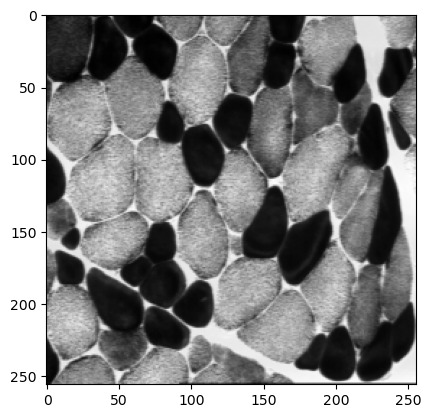

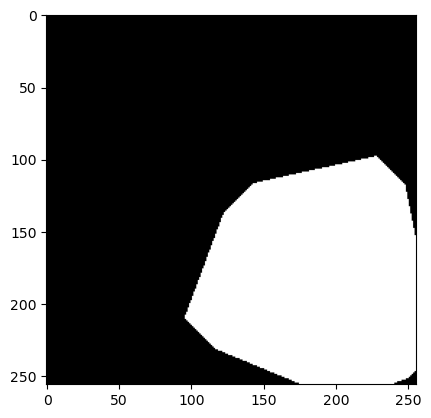

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_muscle = cv2.imread("images/MUSCLE.png", cv2.IMREAD_GRAYSCALE)
image_spot = cv2.imread("images/SPOT.png", cv2.IMREAD_GRAYSCALE)

# Visualizar imagen (MUSCLE)
plt.imshow(image_muscle, cmap="gray")
plt.show()

# Visualizar imagen (MUSCLE)
plt.imshow(image_spot, cmap="gray")
plt.show()

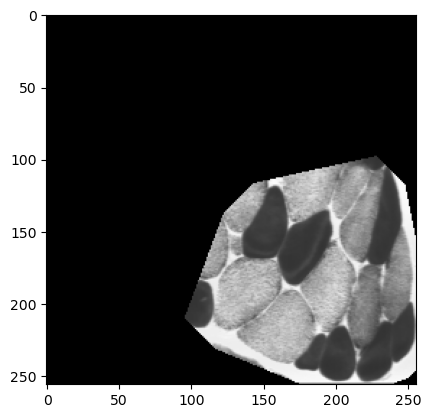

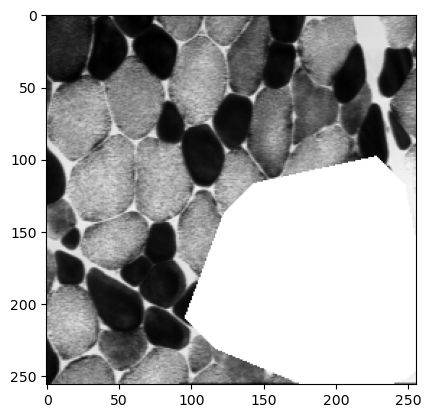

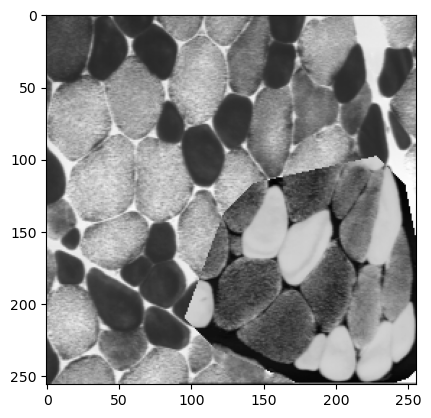

In [ ]:
# Ejecute las operaciones lógicas OR, AND y XOR 
#mask = np.ones(image_muscle.shape, dtype=np.uint8)
dst = cv2.bitwise_and(image_muscle,image_spot,0)

plt.imshow(dst, cmap="gray")
plt.show()

dst = cv2.bitwise_or(image_muscle,image_spot,0)

plt.imshow(dst, cmap="gray")
plt.show()

dst = cv2.bitwise_xor(image_muscle,image_spot,0)

plt.imshow(dst, cmap="gray")
plt.show()


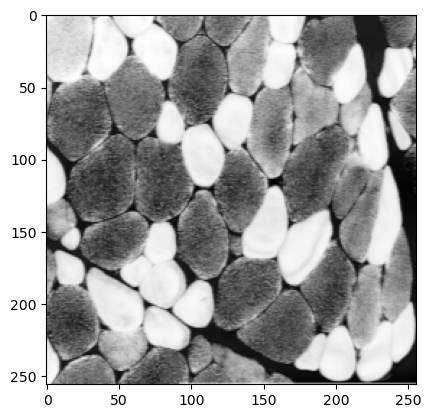

In [35]:
# Operacion NOT usando XOR con imagen toda de 255
white_image = np.ones(image_muscle.shape, dtype=np.uint8) *255

dst = cv2.bitwise_xor(image_muscle, white_image, 0)

plt.imshow(dst, cmap="gray")
plt.show()



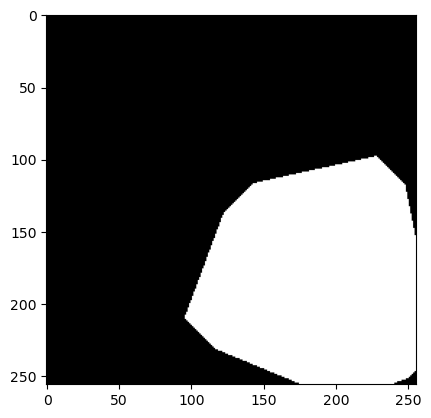

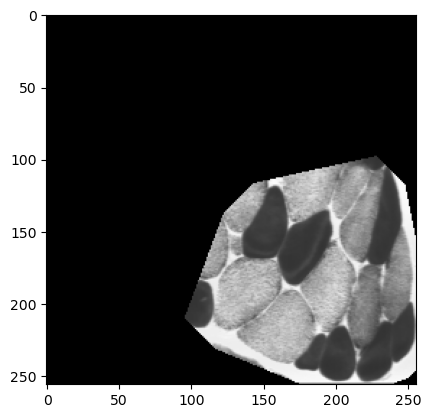

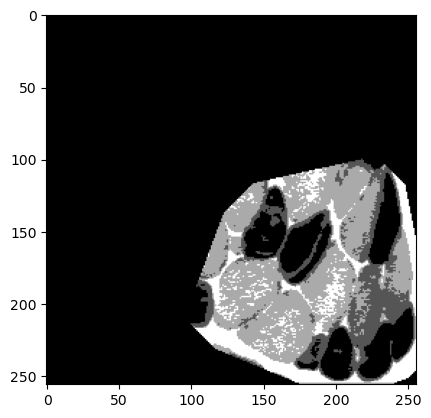

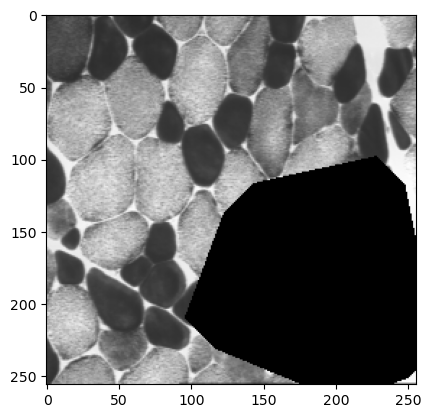

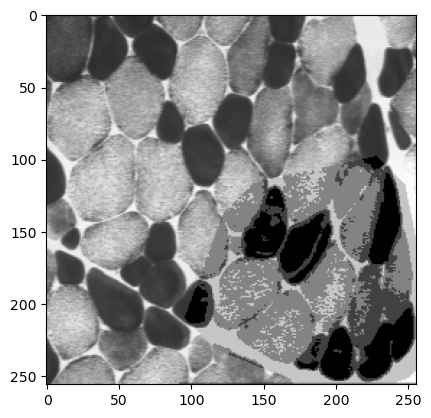

In [ ]:
# Ponga en cero, en la imagen muscle.png, los 6 bits menos significativos de la zona marcada por spot.png (blanca), sin afectar el resto de la imagen

# I want to put logo on top-left corner, So I create a ROI
rows,cols = image_spot.shape
roi = image_muscle[0:rows, 0:cols]

# Now create a mask of spot and create its inverse mask also
ret, mask = cv2.threshold(image_spot, 10, 255, cv2.THRESH_BINARY)
mask_inv = cv2.bitwise_not(mask)

# Visualizar mascara
plt.imshow(mask, cmap="gray")
plt.show()

dst = cv2.bitwise_and(image_muscle,mask,0)
plt.imshow(dst, cmap="gray")
plt.show()

# ---- Cuantificacion al resultado ----
# Cuantificacion de una imagen
def image_quantization(imagen, k):
    plane = np.full((imagen.shape[0], imagen.shape[1]), 255-2 ** k, np.uint8)
    return cv2.bitwise_and(plane, imagen)

img_2bits = dst.copy() #Apagar los 6 planos de bits menos significativos
for k in [0, 1, 2, 3, 4, 5]:
    img_2bits = image_quantization(img_2bits, k)
    
# Visualizar imagen con 6 planos desactivados
plt.imshow(img_2bits, cmap="gray")
plt.show()

# Imagen temporal spot blanco + fondo ideal
# fondo = cv2.bitwise_or(image_muscle, mask, 0)
# plt.imshow(fondo, cmap="gray")
# plt.show()

# Imagen temp spot negro + fondo ideal
temporal = cv2.bitwise_and(image_muscle,mask_inv,0)
plt.imshow(temporal, cmap="gray")
plt.show()

# Imagen final
final_image = cv2.bitwise_or(temporal, img_2bits,0)

# Visualizar imagen final
plt.imshow(final_image, cmap="gray")
plt.show()